# **Assignment 03: SAM**

**Available:** Sep 2, 2025 until Sep 11, 2025 11:59pm

## Tasks:
1. https://wwww.kaggle.com/datasets/carlolepelaars/camvid
    - Use the validation datset
2. Design an algorithm that:
    - You do not need to MANUALLY click, draw a box/mask to run SAM2
    - For example, give a text prompt to SAM2 <- Baseline
    - Invent another one that can beat the baseline algorithm
    - Segment people and vehicles
    - Use Dice Score for Comparisons
3. Same Grading: Report, code, video, insight 



## **Import Packages and Setup**

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables
Found Hugging Face token in environment variables


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl


In [3]:
# GPU Setup 
# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> mps (Apple Silicon) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    elif device.type == 'mps':
        # MPS doesn't have direct memory monitoring like CUDA
        # Return 0 as a placeholder
        return 0
    return 0


=== GPU Diagnostics ===
PyTorch version: 2.8.0
CUDA available: False
MPS available: True
CUDA version: None
Number of GPUs detected: 0
Using Apple Silicon MPS
Selected device: mps


## **Import and Process Dataset**


In [4]:
import glob
from PIL import Image
import cv2

class CamVidDataset(Dataset):
    """
    CamVid Dataset class for SAM2 segmentation
    """
    def __init__(self, data_root="data/CamVid", split="val", transform=None):
        self.data_root = data_root
        self.split = split
        self.transform = transform
        
        # Set paths
        self.images_dir = os.path.join(data_root, split)
        self.labels_dir = os.path.join(data_root, f"{split}_labels")
        
        # Get image files
        self.image_files = sorted(glob.glob(os.path.join(self.images_dir, "*.png")))
        
        # Verify that labels exist for all images
        self.label_files = []
        for img_path in self.image_files:
            img_name = os.path.basename(img_path)
            label_name = img_name.replace('.png', '_L.png')
            label_path = os.path.join(self.labels_dir, label_name)
            if os.path.exists(label_path):
                self.label_files.append(label_path)
            else:
                print(f"Warning: No label found for {img_name}")
        
        # Ensure equal number of images and labels
        assert len(self.image_files) == len(self.label_files), \
            f"Mismatch: {len(self.image_files)} images vs {len(self.label_files)} labels"
        
        print(f"Loaded {len(self.image_files)} image-label pairs from {split} split")
        
        # Load class dictionary
        self.class_dict = self._load_class_dict()
        self.people_vehicle_classes = self._define_target_classes()
        
    def _load_class_dict(self):
        """Load class dictionary from CSV"""
        class_dict_path = os.path.join(self.data_root, "class_dict.csv")
        df = pd.read_csv(class_dict_path)
        
        # Create RGB to class name mapping
        rgb_to_class = {}
        for _, row in df.iterrows():
            rgb_key = (int(row['r']), int(row['g']), int(row['b']))
            rgb_to_class[rgb_key] = row['name']
        
        return rgb_to_class
    
    def _define_target_classes(self):
        """Define people and vehicle classes with their RGB values"""
        people_classes = {
            'Pedestrian': (64, 64, 0),
            'Bicyclist': (0, 128, 192),  
            'Child': (192, 128, 64),
        }
        
        vehicle_classes = {
            'Car': (64, 0, 128),
            'SUVPickupTruck': (64, 128, 192),
            'Truck_Bus': (192, 128, 192),
            'MotorcycleScooter': (192, 0, 192),
        }
        
        return {
            'people': people_classes,
            'vehicles': vehicle_classes
        }
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_files[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load label
        label_path = self.label_files[idx]
        label = cv2.imread(label_path)
        label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)
        
        # Get people and vehicle masks
        people_mask, vehicle_mask = self.get_people_vehicle_masks(label)
        
        # Create sample dictionary
        sample = {
            'image': image,
            'label': label,
            'people_mask': people_mask,
            'vehicle_mask': vehicle_mask,
            'image_path': img_path,
            'label_path': label_path,
            'image_name': os.path.basename(img_path),
            'height': image.shape[0],
            'width': image.shape[1]
        }
        
        if self.transform:
            sample = self.transform(sample)
            
        return sample
    
    def get_people_vehicle_masks(self, label_array):
        """
        Extract people and vehicle masks from segmentation label
        CamVid uses RGB labels, so we match RGB values to classes
        """
        people_mask = np.zeros_like(label_array[:,:,0], dtype=bool)
        vehicle_mask = np.zeros_like(label_array[:,:,0], dtype=bool)
        
        # Create masks for people classes
        for class_name, (r, g, b) in self.people_vehicle_classes['people'].items():
            class_mask = (label_array[:,:,0] == r) & (label_array[:,:,1] == g) & (label_array[:,:,2] == b)
            people_mask |= class_mask
            
        # Create masks for vehicle classes  
        for class_name, (r, g, b) in self.people_vehicle_classes['vehicles'].items():
            class_mask = (label_array[:,:,0] == r) & (label_array[:,:,1] == g) & (label_array[:,:,2] == b)
            vehicle_mask |= class_mask
            
        return people_mask, vehicle_mask
    
    def get_class_stats(self):
        """Get statistics about people and vehicle pixels in the dataset"""
        stats = {
            'people': {'total_pixels': 0, 'images_with_people': 0},
            'vehicles': {'total_pixels': 0, 'images_with_vehicles': 0}
        }
        
        for idx in tqdm(range(len(self)), desc="Computing class statistics"):
            sample = self[idx]
            people_mask = sample['people_mask']
            vehicle_mask = sample['vehicle_mask']
            
            people_pixels = np.sum(people_mask)
            vehicle_pixels = np.sum(vehicle_mask)
            
            stats['people']['total_pixels'] += people_pixels
            stats['vehicles']['total_pixels'] += vehicle_pixels
            
            if people_pixels > 0:
                stats['people']['images_with_people'] += 1
            if vehicle_pixels > 0:
                stats['vehicles']['images_with_vehicles'] += 1
        
        return stats


def create_camvid_dataloader(data_root="data/CamVid", split="val", batch_size=1, shuffle=False, num_workers=0):
    """
    Create DataLoader for CamVid dataset
    
    Args:
        data_root: Path to CamVid dataset
        split: Dataset split ('val' for validation)
        batch_size: Batch size (typically 1 for SAM2)
        shuffle: Whether to shuffle data
        num_workers: Number of worker processes (0 for single-threaded)
    
    Returns:
        DataLoader object
    """
    dataset = CamVidDataset(data_root=data_root, split=split)
    
    dataloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    return dataloader


# Create the validation dataloader
print("Creating CamVid validation dataloader...")
val_dataloader = create_camvid_dataloader(
    data_root="data/CamVid",
    split="val", 
    batch_size=1,  # SAM2 typically processes one image at a time
    shuffle=False,  # Keep consistent order for validation
    num_workers=0   # Set to 0 to avoid multiprocessing issues
)

print(f"Validation dataloader created with {len(val_dataloader)} samples")

# Get dataset statistics
dataset = val_dataloader.dataset
class_stats = dataset.get_class_stats()

print("\n=== Dataset Statistics ===")
print(f"Total images: {len(dataset)}")
print(f"People - Images with people: {class_stats['people']['images_with_people']}")
print(f"People - Total pixels: {class_stats['people']['total_pixels']:,}")
print(f"Vehicles - Images with vehicles: {class_stats['vehicles']['images_with_vehicles']}")
print(f"Vehicles - Total pixels: {class_stats['vehicles']['total_pixels']:,}")

# Print target classes
print("\n=== Target Classes ===")
print("People classes:")
for name, rgb in dataset.people_vehicle_classes['people'].items():
    print(f"  {name}: RGB{rgb}")

print("Vehicle classes:")
for name, rgb in dataset.people_vehicle_classes['vehicles'].items():
    print(f"  {name}: RGB{rgb}")

Creating CamVid validation dataloader...
Loaded 100 image-label pairs from val split
Validation dataloader created with 100 samples


Computing class statistics:   0%|          | 0/100 [00:00<?, ?it/s]


=== Dataset Statistics ===
Total images: 100
People - Images with people: 93
People - Total pixels: 770,974
Vehicles - Images with vehicles: 98
Vehicles - Total pixels: 3,309,683

=== Target Classes ===
People classes:
  Pedestrian: RGB(64, 64, 0)
  Bicyclist: RGB(0, 128, 192)
  Child: RGB(192, 128, 64)
Vehicle classes:
  Car: RGB(64, 0, 128)
  SUVPickupTruck: RGB(64, 128, 192)
  Truck_Bus: RGB(192, 128, 192)
  MotorcycleScooter: RGB(192, 0, 192)


Showing 3 samples from the dataset...


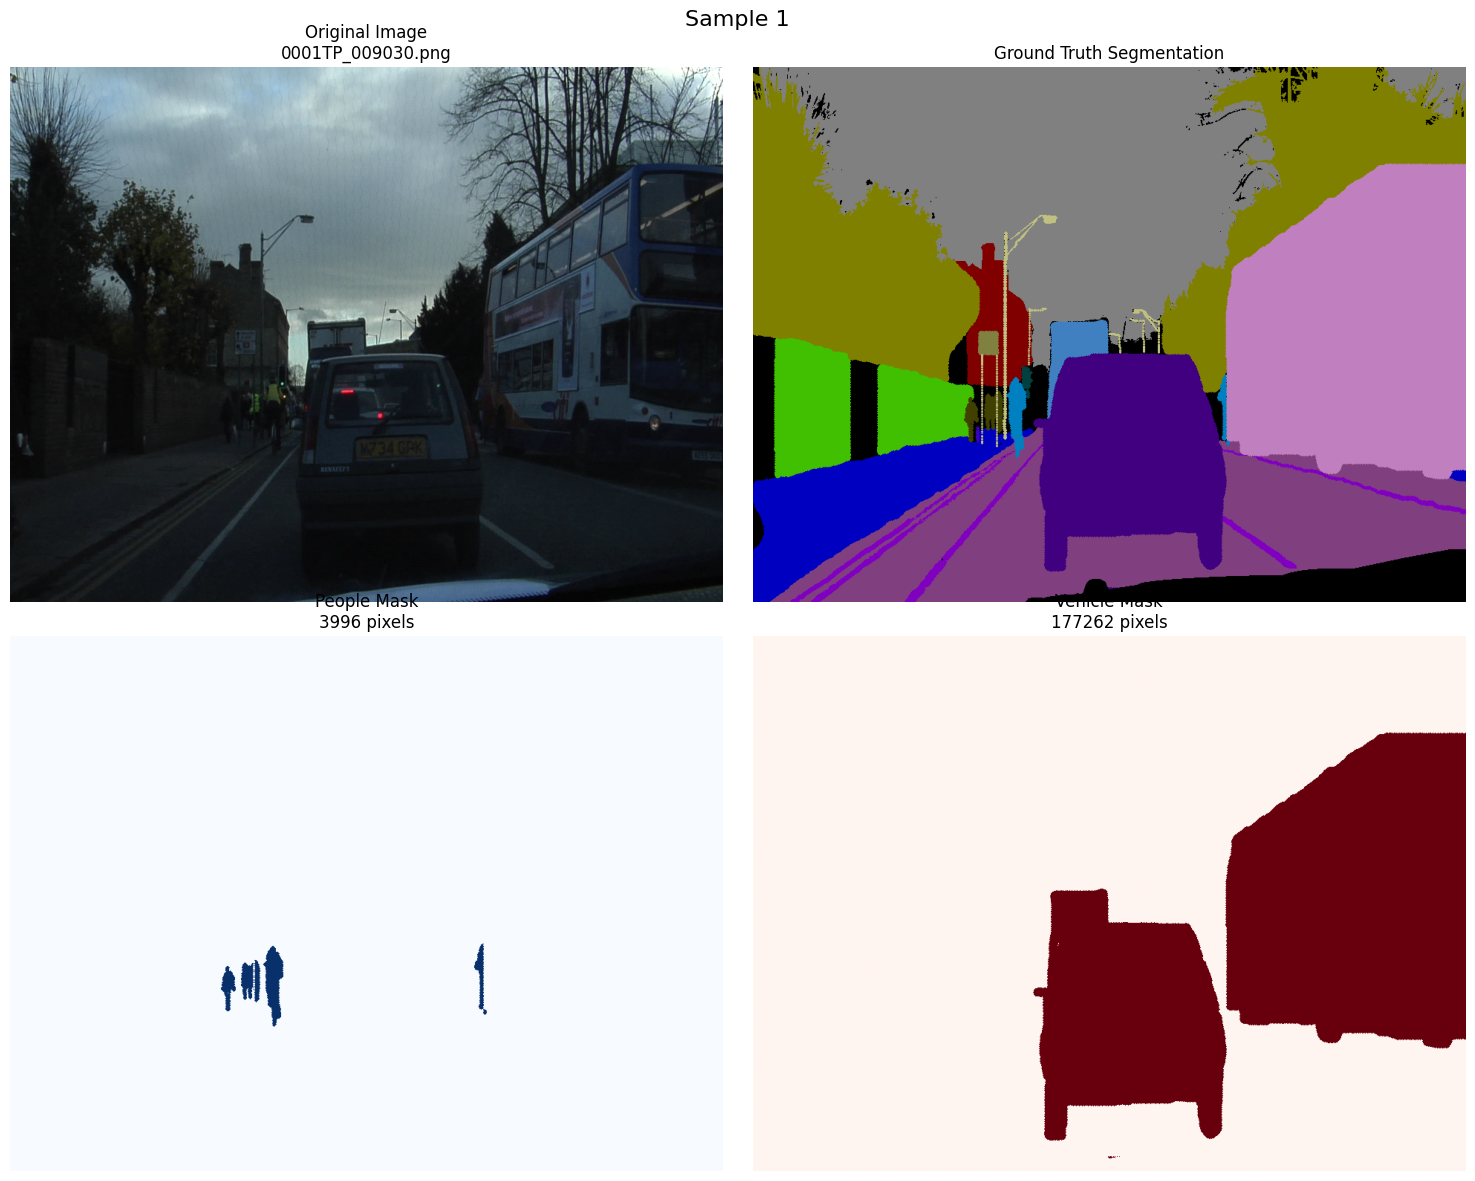

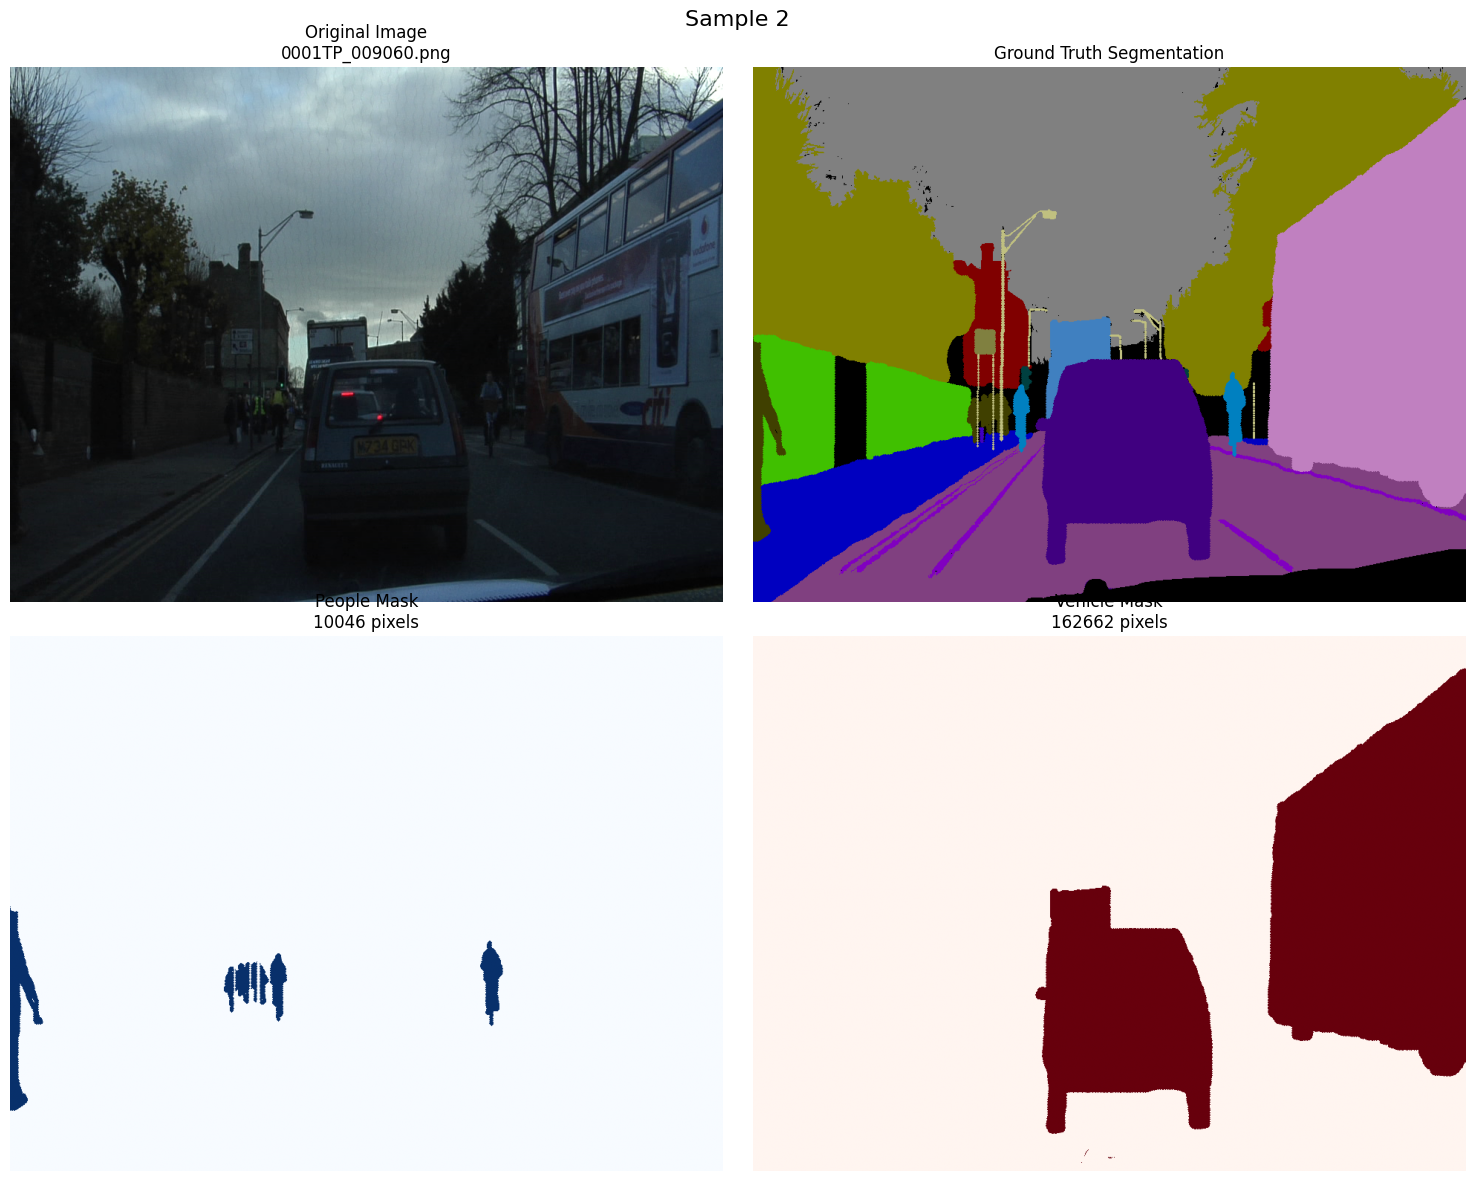

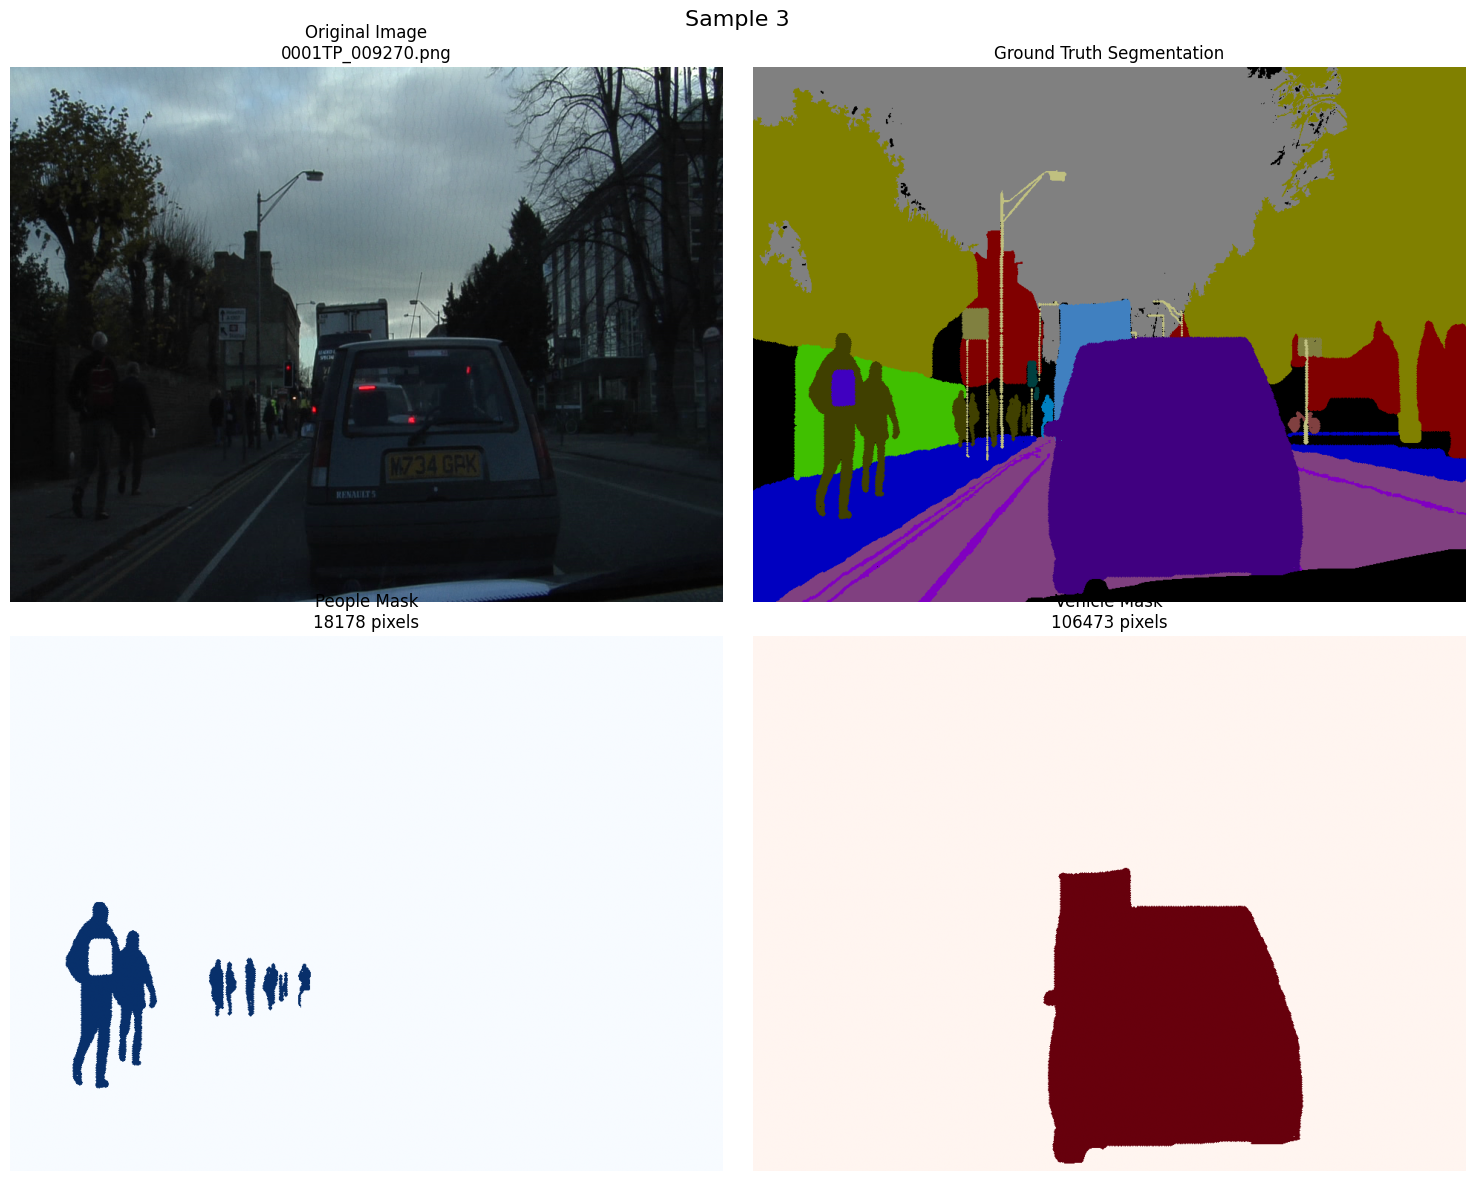

In [5]:
def visualize_sample(sample, title="Sample Visualization"):
    """
    Visualize a sample from the dataset with original image, ground truth masks
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    # Original image
    axes[0, 0].imshow(sample['image'])
    axes[0, 0].set_title(f"Original Image\n{sample['image_name']}")
    axes[0, 0].axis('off')
    
    # Ground truth segmentation (RGB labels)
    axes[0, 1].imshow(sample['label'])
    axes[0, 1].set_title("Ground Truth Segmentation")
    axes[0, 1].axis('off')
    
    # People mask
    axes[1, 0].imshow(sample['people_mask'], cmap='Blues')
    axes[1, 0].set_title(f"People Mask\n{np.sum(sample['people_mask'])} pixels")
    axes[1, 0].axis('off')
    
    # Vehicle mask
    axes[1, 1].imshow(sample['vehicle_mask'], cmap='Reds')
    axes[1, 1].set_title(f"Vehicle Mask\n{np.sum(sample['vehicle_mask'])} pixels")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


def show_dataset_samples(dataloader, num_samples=3):
    """
    Show multiple samples from the dataset
    """
    print(f"Showing {num_samples} samples from the dataset...")
    
    for i, batch in enumerate(dataloader):
        if i >= num_samples:
            break
            
        # Extract sample from batch (batch_size=1)
        sample = {
            'image': batch['image'][0].numpy(),
            'label': batch['label'][0].numpy(), 
            'people_mask': batch['people_mask'][0].numpy(),
            'vehicle_mask': batch['vehicle_mask'][0].numpy(),
            'image_name': batch['image_name'][0],
        }
        
        visualize_sample(sample, title=f"Sample {i+1}")


# Visualize some samples
show_dataset_samples(val_dataloader, num_samples=3)

In [7]:
def calculate_dice_score(pred_mask, gt_mask, smooth=1e-6):
    """
    Calculate Dice score between prediction and ground truth masks
    
    Args:
        pred_mask: Predicted binary mask (numpy array)
        gt_mask: Ground truth binary mask (numpy array)
        smooth: Smoothing factor to avoid division by zero
    
    Returns:
        dice_score: Dice coefficient (0-1, higher is better)
    """
    # Ensure masks are boolean
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    
    # Calculate intersection and union
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    total = pred_mask.sum() + gt_mask.sum()
    
    # Calculate Dice score
    dice_score = (2.0 * intersection + smooth) / (total + smooth)
    
    return dice_score


def calculate_iou_score(pred_mask, gt_mask, smooth=1e-6):
    """
    Calculate IoU (Intersection over Union) score
    
    Args:
        pred_mask: Predicted binary mask (numpy array)
        gt_mask: Ground truth binary mask (numpy array) 
        smooth: Smoothing factor to avoid division by zero
    
    Returns:
        iou_score: IoU coefficient (0-1, higher is better)
    """
    # Ensure masks are boolean
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    
    # Calculate intersection and union
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    
    # Calculate IoU score
    iou_score = (intersection + smooth) / (union + smooth)
    
    return iou_score


def evaluate_segmentation(pred_mask, gt_mask):
    """
    Comprehensive evaluation of segmentation results
    
    Returns:
        dict: Dictionary containing multiple evaluation metrics
    """
    dice = calculate_dice_score(pred_mask, gt_mask)
    iou = calculate_iou_score(pred_mask, gt_mask)
    
    # Additional metrics
    precision = np.sum(np.logical_and(pred_mask, gt_mask)) / (np.sum(pred_mask) + 1e-6)
    recall = np.sum(np.logical_and(pred_mask, gt_mask)) / (np.sum(gt_mask) + 1e-6)
    
    return {
        'dice': dice,
        'iou': iou,
        'precision': precision,
        'recall': recall
    }


print("Dataset loading and evaluation functions ready!")
print("Next steps:")
print("1. The dataloader is ready for SAM2 inference")
print("2. Use val_dataloader to iterate through validation samples")
print("3. For each sample, you can access:")
print("   - sample['image']: Original RGB image")
print("   - sample['people_mask']: Ground truth people mask")
print("   - sample['vehicle_mask']: Ground truth vehicle mask")
print("4. Use calculate_dice_score() to evaluate SAM2 predictions against ground truth")

Dataset loading and evaluation functions ready!
Next steps:
1. The dataloader is ready for SAM2 inference
2. Use val_dataloader to iterate through validation samples
3. For each sample, you can access:
   - sample['image']: Original RGB image
   - sample['people_mask']: Ground truth people mask
   - sample['vehicle_mask']: Ground truth vehicle mask
4. Use calculate_dice_score() to evaluate SAM2 predictions against ground truth


## **Import SAM2 Model**
Source: https://huggingface.co/facebook/sam2.1-hiera-large <br />
Source: https://github.com/huggingface/segment-anything-2 <br />
Source: https://huggingface.co/docs/transformers/main/model_doc/sam2

In [5]:
# For Image Prediction Example Test from HuggingFace

from transformers import pipeline

generator = pipeline("mask-generation", model="facebook/sam2.1-hiera-large", device=0)
image_url = "https://huggingface.co/datasets/hf-internal-testing/sam2-fixtures/resolve/main/truck.jpg"
outputs = generator(image_url, points_per_batch=64)

print("Number of masks generated:", len(outputs["masks"]))


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use mps:0


Number of masks generated: 31


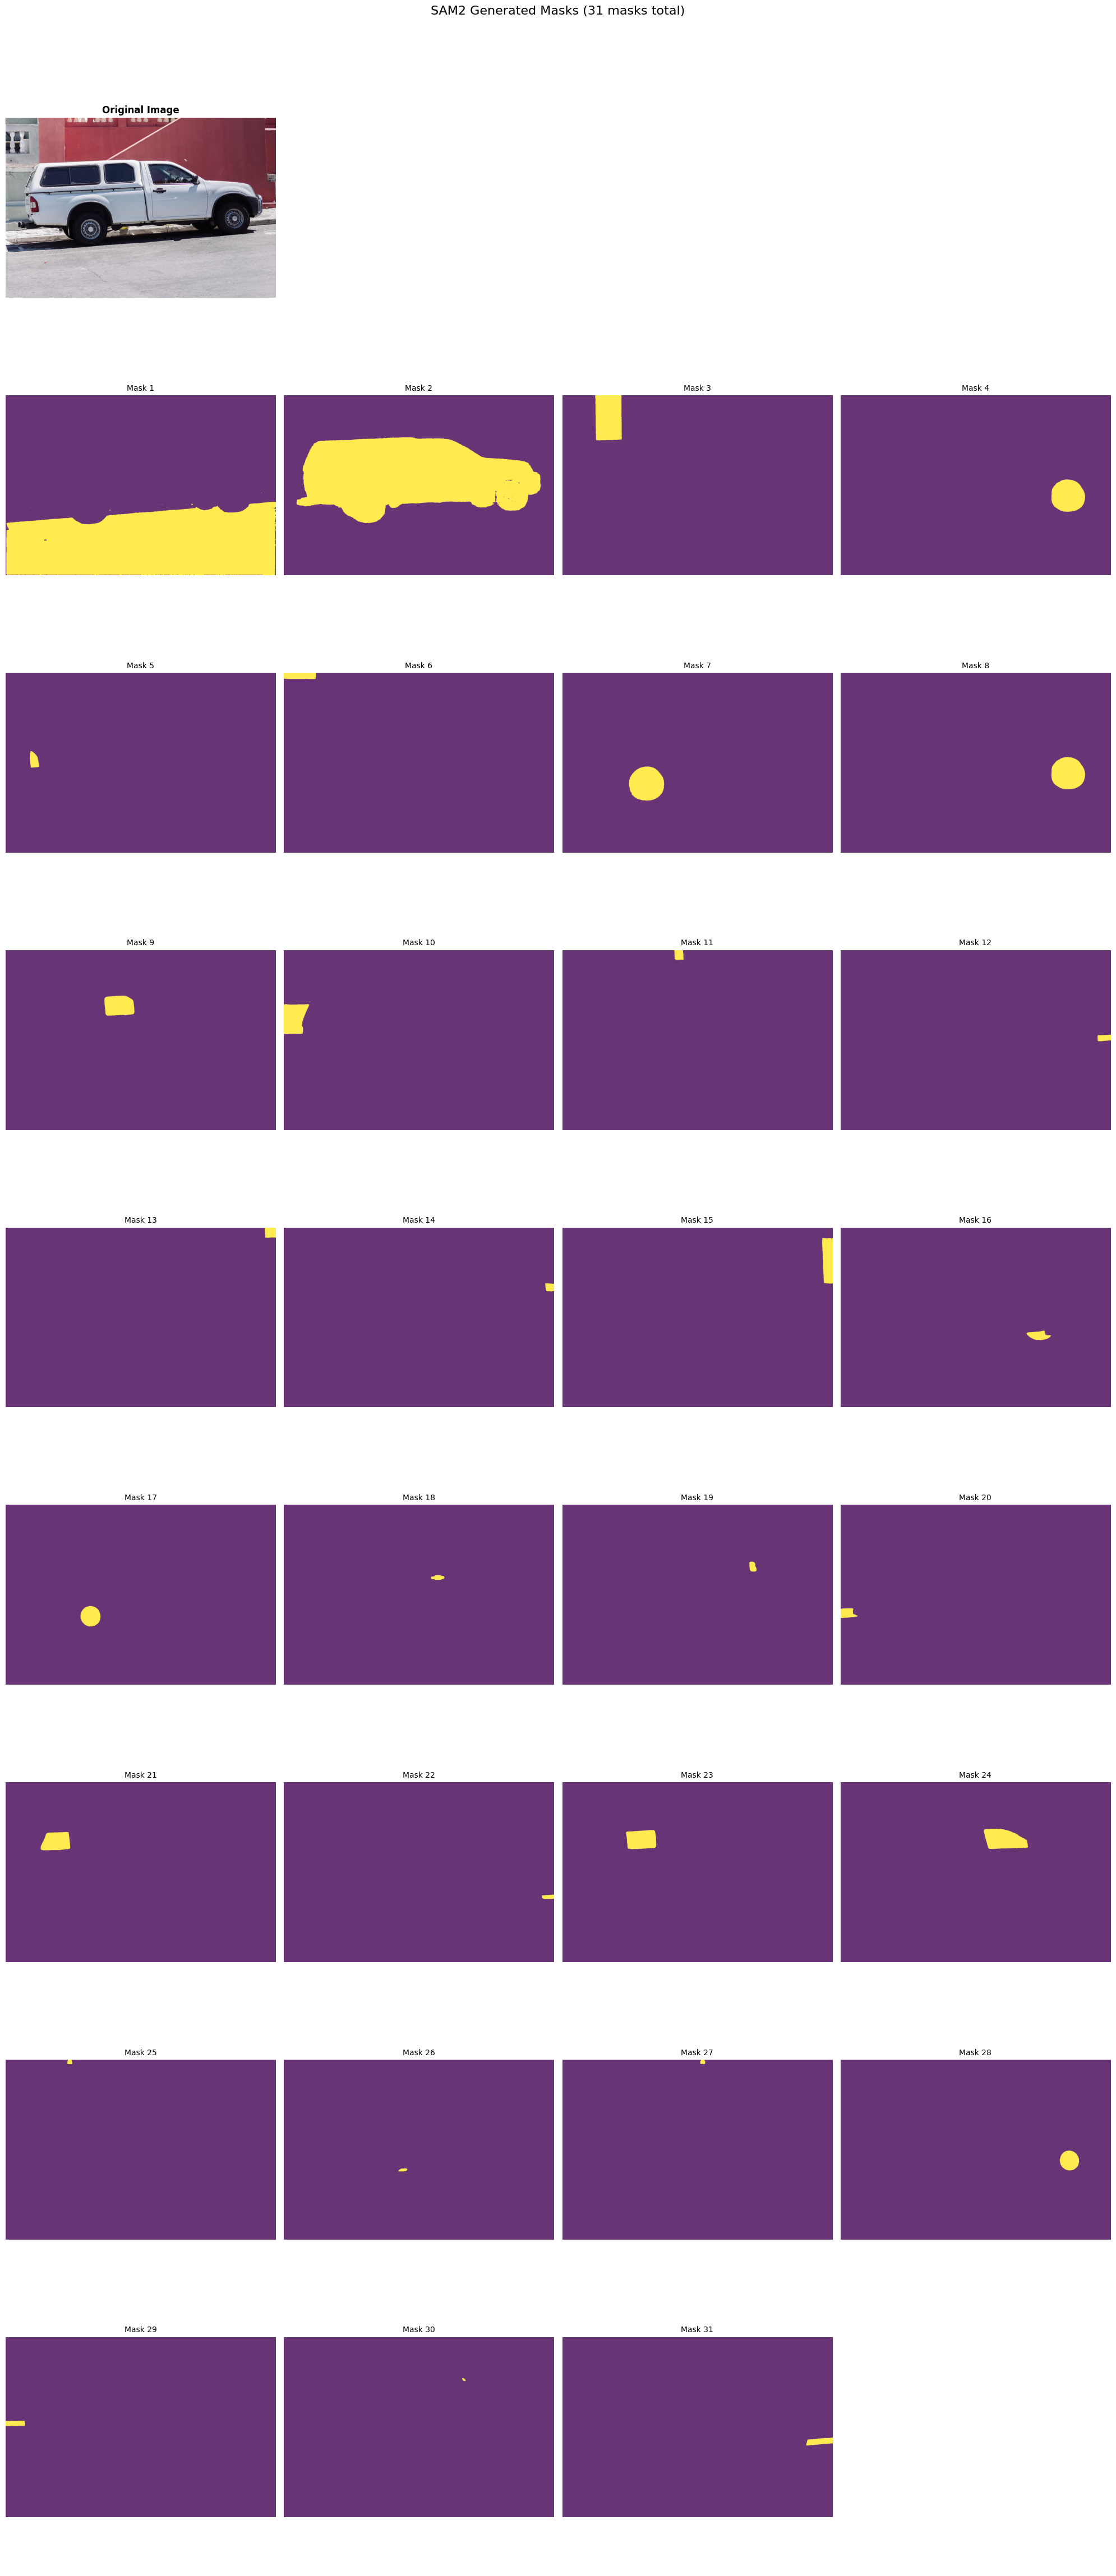

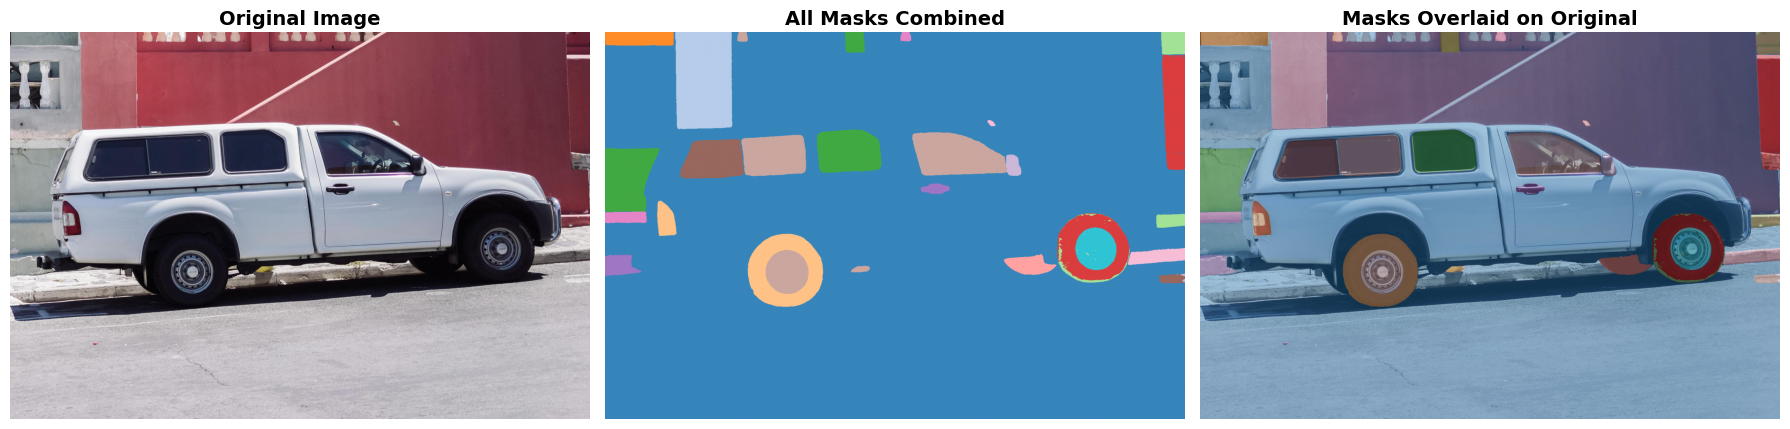

Visualization complete!
Generated 31 masks from the truck image
Image shape: (1200, 1800, 3)
Mask shape: torch.Size([1200, 1800])


In [6]:
# Visualize the generated masks
import requests
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the original image
response = requests.get(image_url)
original_image = Image.open(requests.get(image_url, stream=True).raw)
original_image = np.array(original_image)

# Create visualization
num_masks = len(outputs["masks"])
cols = 4  # Number of columns for the grid
rows = (num_masks + cols) // cols + 1  # +1 for the original image

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)

# Show original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Hide unused subplots in the first row
for j in range(1, cols):
    axes[0, j].axis('off')

# Show generated masks
for i, mask in enumerate(outputs["masks"]):
    row = (i + cols) // cols
    col = (i + cols) % cols
    
    # Convert mask to numpy array if needed
    if hasattr(mask, 'numpy'):
        mask_array = mask.numpy()
    else:
        mask_array = np.array(mask)
    
    # Display mask
    axes[row, col].imshow(mask_array, cmap='viridis', alpha=0.8)
    axes[row, col].set_title(f"Mask {i+1}", fontsize=10)
    axes[row, col].axis('off')

# Hide any remaining empty subplots
total_plots = num_masks + cols
for i in range(total_plots, rows * cols):
    row = i // cols
    col = i % cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.suptitle(f"SAM2 Generated Masks ({num_masks} masks total)", fontsize=16, y=1.02)
plt.show()

# Also create an overlay visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(original_image)
axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
axes[0].axis('off')

# All masks combined
combined_mask = np.zeros_like(outputs["masks"][0], dtype=float)
for i, mask in enumerate(outputs["masks"]):
    if hasattr(mask, 'numpy'):
        mask_array = mask.numpy()
    else:
        mask_array = np.array(mask)
    combined_mask += mask_array * (i + 1) / len(outputs["masks"])

axes[1].imshow(combined_mask, cmap='tab20', alpha=0.9)
axes[1].set_title("All Masks Combined", fontsize=14, fontweight='bold')
axes[1].axis('off')

# Overlay on original image
axes[2].imshow(original_image)
axes[2].imshow(combined_mask, cmap='tab20', alpha=0.4)
axes[2].set_title("Masks Overlaid on Original", fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Visualization complete!")
print(f"Generated {num_masks} masks from the truck image")
print(f"Image shape: {original_image.shape}")
print(f"Mask shape: {outputs['masks'][0].shape if outputs['masks'] else 'N/A'}")